In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="datetime.datetime.utcnow() is deprecated")
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
!pip install -U langchain langchain-core langchain-community langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.43.0, but you have google-auth 2.45.0 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
!pip install langchain_google_genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.6/426.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.43.0
    Uninstalling google-auth-2.43.0:
      Successfully uninstalled google-auth-2.43.0
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.1
    Uninstalling langchain-core-1.2.1:
      Successfully uninstalled langchain-core-1.2.1
  Attempting uninstall: google-genai
    Found existing installation: google-genai 1.55.0
    Uninstalling google-genai-1.55.0:
      Successfully uninstalled google-genai-1.55.0
ERROR: pip's dependency resolver does not currently take into a

# Read Data

In [ ]:
# path = '/content/drive/MyDrive/Datasets/job_descriptions.csv'
# path = '/content/job_desc_norm.csv'
# path = '/content/job_desc_norm (1).csv'
path = '/content/drive/MyDrive/Datasets/job_desc_norm.csv'

jd = pd.read_csv(path)
jd

,Unnamed: 0,title,company,company_image_url,location,description,site,job_url,it_role_type,main_programming_languages,key_technologies,city
0,0,iOS Developer (Swift),VNPAY,https://itviec.com/rails/active_storage/repres...,"22 Láng Hạ, Dong Da, Ha Noi; Tầng 12, tòa nhà...",Top 3 reasons to join us\n- Lương và chế độ hấ...,ITViec,https://itviec.com/it-jobs/ios-developer-swift...,Mobile Developer,['Swift'],"['xCode', 'Realm', 'REST', 'JSON', 'Objective-C']",Hà Nội
1,1,"5 Fullstack Dev (Java, Spring, Angular)",LEAP,https://itviec.com/rails/active_storage/repres...,"199 Dien Bien Phu, Binh Thanh, Ho Chi Minh",Top 3 reasons to join us\n- 18+ days of annual...,ITViec,https://itviec.com/it-jobs/5-fullstack-dev-jav...,Full Stack Developer,"['Java', 'JavaScript', 'HTML/CSS']","['Spring Boot', 'Angular', 'React', 'Agile']",Hồ Chí Minh
2,2,"Mid/Senior Frontend Developer (Next.js, Tailwi...","Local Life Technology Ltd.,",https://itviec.com/rails/active_storage/repres...,"63 Nguyễn Hiến Lê, phường Hoà Xuân, Cam Le, Da...",LocalLife.Asia là nền tảng kết nối du khách vớ...,ITViec,https://itviec.com/it-jobs/mid-senior-frontend...,Frontend Engineer,['TypeScript'],"['Next.js', 'Tailwind CSS']",Đà Nẵng
3,3,"Atlassian ITSM Development Engineer (ITSM, Pyt...",TymeX,https://itviec.com/rails/active_storage/repres...,"Level 5 - 6, East Tower, Lumiere Riverside, 27...",TymeX is an innovative digital banking develop...,ITViec,https://itviec.com/it-jobs/atlassian-itsm-deve...,System Engineer,['Python'],"['JIRA Service Management', 'Confluence', 'Ops...",Hồ Chí Minh
4,4,Junior QC Engineer (Tester/QA QC),Fastboy Marketing,https://itviec.com/rails/active_storage/repres...,"56A Le Khoi, Phu Thanh, Tan Phu, Ho Chi Minh",We are building an environment where personal ...,ITViec,https://itviec.com/it-jobs/junior-qc-engineer-...,QA Engineer,[],"['Agile', 'Automated Testing', 'Performance Te...",Hồ Chí Minh
...,...,...,...,...,...,...,...,...,...,...,...,...
3096,3096,Fullstack Web Developer,CÔNG TY TNHH ROYALMAN,https://cdn-new.topcv.vn/unsafe/80x/https://st...,"Hồ Chí Minh, Quận 7",Mô tả công việc\n- Being part of the VN Softwa...,TopCV,https://www.topcv.vn/viec-lam/fullstack-web-de...,Full Stack Developer,"['JavaScript', 'NodeJS']","['React', 'AWS', 'Google Cloud', 'Kafka', 'Doc...",Hồ Chí Minh
3097,3097,Backend Developer (AWS),Công Ty Cổ Phần Vàng Bạc Đá quý Phú Nhuận - PNJ,https://cdn-new.topcv.vn/unsafe/80x/https://st...,Hồ Chí Minh,Mô tả công việc\n- Develop and maintain high-p...,TopCV,https://www.topcv.vn/viec-lam/backend-develope...,Backend Engineer,"['Python', 'Node.js']","['AWS', 'Serverless Architecture', 'CI/CD', 'I...",Hồ Chí Minh
3098,3098,Lập Trình Wordpress Developer,Công ty TNHH Đầu tư Thương Mại Flexhouse,https://cdn-new.topcv.vn/unsafe/80x/https://st...,Hồ Chí Minh,"• Thiết kế, lập trình và phát triển các websit...",TopCV,https://www.topcv.vn/viec-lam/lap-trinh-wordpr...,Backend Engineer,"['PHP', 'HTML', 'CSS', 'JavaScript', 'SQL']","['WordPress', 'SEO', 'Git']",Hồ Chí Minh
3099,3099,Phần Mềm,Công ty TNHH Med-Aid,https://www.topcv.vn/v4/image/normal-company/l...,Hà Nội,Mô tả công việc\n1. Phát triển và tích hợp hệ ...,TopCV,https://www.topcv.vn/viec-lam/phan-mem/1761008...,Full Stack Developer,"['Python', 'C', 'JavaScript']","['Django', 'FastAPI', 'Flask', 'React', 'Flutt...",Hà Nội


In [ ]:
print(jd.shape)
print(jd.columns)
print(jd.iloc[0])

(3101, 12)
Index(['Unnamed: 0', 'title', 'company', 'company_image_url', 'location',
       'description', 'site', 'job_url', 'it_role_type',
       'main_programming_languages', 'key_technologies', 'city'],
      dtype='object')
Unnamed: 0                                                                    0
title                                                     iOS Developer (Swift)
company                                                                   VNPAY
company_image_url             https://itviec.com/rails/active_storage/repres...
location                      22  Láng Hạ, Dong Da, Ha Noi; Tầng 12, tòa nhà...
description                   Top 3 reasons to join us\n- Lương và chế độ hấ...
site                                                                     ITViec
job_url                       https://itviec.com/it-jobs/ios-developer-swift...
it_role_type                                                   Mobile Developer
main_programming_languages                        

# Visualization (Shallow Data Mining)

In [ ]:
# !pip install ydata-profiling

In [ ]:
# from ydata_profiling import ProfileReport
# profile = ProfileReport(jd, title="Profiling Report")
# # profile.to_file("report.html")

## Site Job

In [ ]:
from collections import Counter
count_sitejob = Counter(jd['site'])
print(count_sitejob)
common_sitejob = count_sitejob.most_common()
df_most_common_sitejob = pd.DataFrame(common_sitejob, columns=['Site Job', 'Count'])
df_most_common_sitejob

Counter({'TopCV': 1133, 'LinkedIn': 1039, 'ITViec': 929})


,Site Job,Count
0,TopCV,1133
1,LinkedIn,1039
2,ITViec,929


/tmp/ipython-input-45483935.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


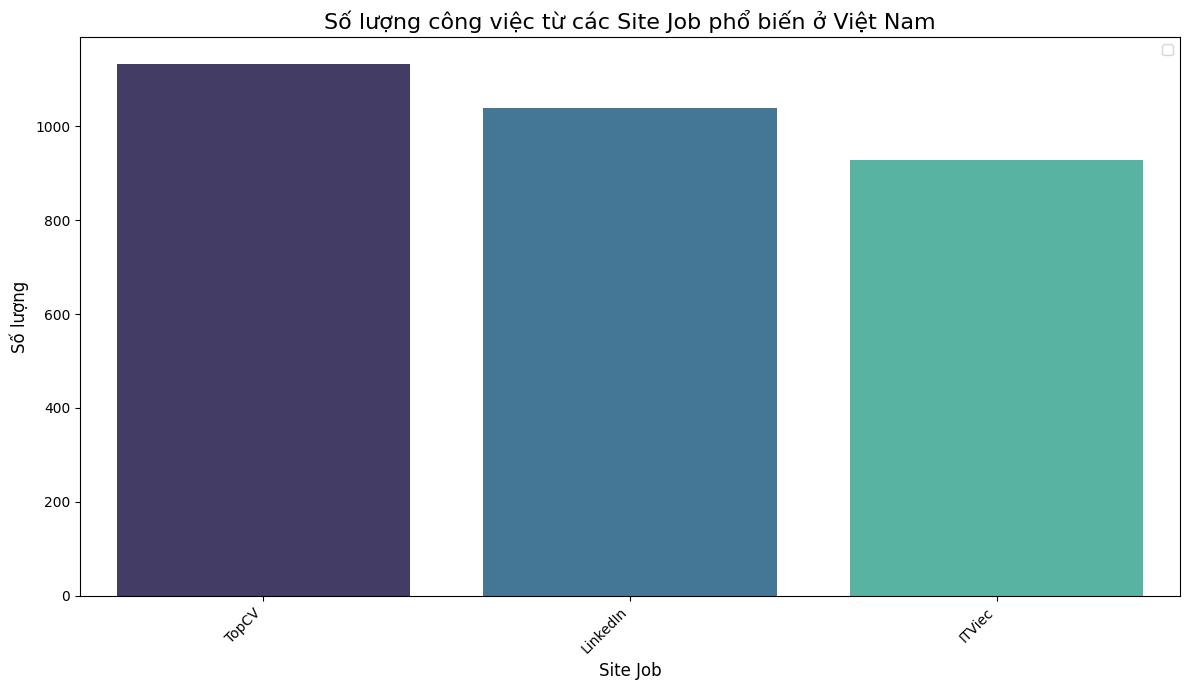

In [ ]:
plt.figure(figsize = (12, 7))
sns.barplot(data = df_most_common_sitejob, x = 'Site Job', y = 'Count', palette='mako', hue='Site Job', legend=False)
plt.title("Số lượng công việc từ các Site Job phổ biến ở Việt Nam", fontsize=16)
plt.xlabel("Site Job", fontsize = 12)
plt.ylabel("Số lượng", fontsize = 12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

/tmp/ipython-input-281743587.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Site Job", y="Count", data=df_most_common_sitejob, ax=axes[0], palette="Set2")


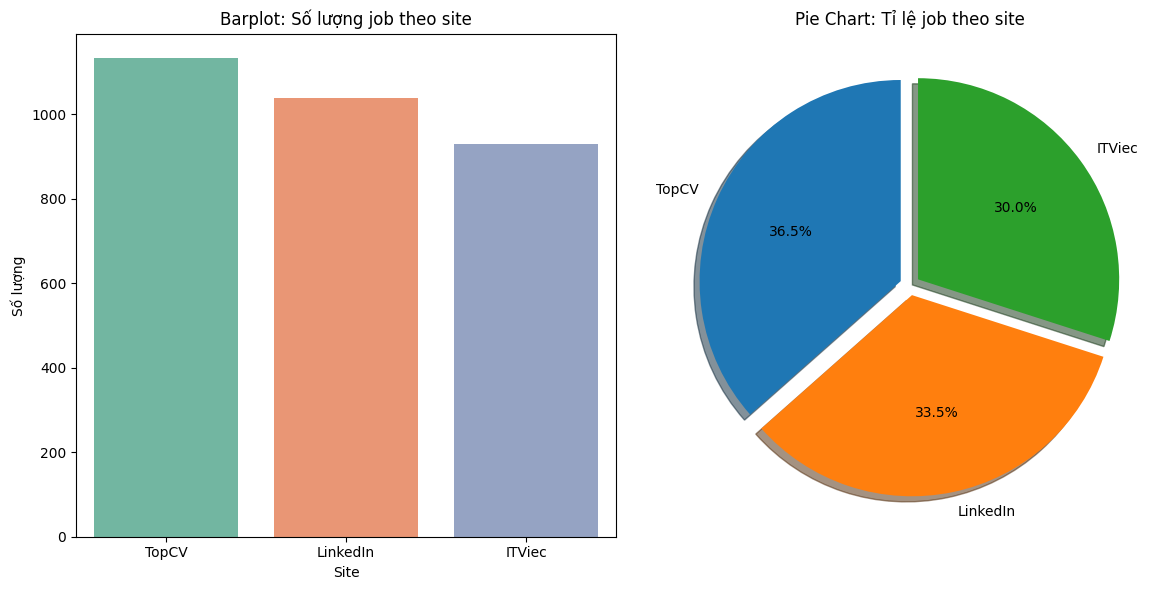

In [ ]:
# Dữ liệu
labels = df_most_common_sitejob["Site Job"]
sizes = df_most_common_sitejob["Count"]

fig, axes = plt.subplots(1, 2, figsize=(12,6))

sns.barplot(x="Site Job", y="Count", data=df_most_common_sitejob, ax=axes[0], palette="Set2")
axes[0].set_title("Barplot: Số lượng job theo site")
axes[0].set_xlabel("Site")
axes[0].set_ylabel("Số lượng")

axes[1].pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=[0.05]*len(labels)   # tách nhẹ tất cả
)
axes[1].set_title("Pie Chart: Tỉ lệ job theo site")

# Hiển thị toàn bộ
plt.tight_layout()
plt.show()

## City

In [ ]:
top_city = 6
count_location = Counter(jd['city'])
print(count_location)
common_location = count_location.most_common(top_city)
df_most_common_location = pd.DataFrame(common_location, columns=['City', 'Jobs'])
df_most_common_location.drop(df_most_common_location.index[2], inplace=True)
df_most_common_location

Counter({'Hà Nội': 1390, 'Hồ Chí Minh': 1365, 'Not Specified': 134, 'Đà Nẵng': 126, 'Bắc Ninh': 17, 'Hải Phòng': 9, 'Thái Nguyên': 9, 'Bình Dương': 8, 'Nghệ An': 6, 'Đồng Nai': 6, 'Bắc Giang': 4, 'Cần Thơ': 4, 'Ninh Bình': 4, 'Hà Tĩnh': 3, 'Hưng Yên': 3, 'Nha Trang': 3, 'Đồng Tháp': 2, 'Bà Rịa-Vũng Tàu': 2, 'Khánh Hoà': 2, 'Ho Chi Minh': 1, 'Can Tho': 1, 'Vĩnh Phúc': 1, 'Hải Dương': 1})


,City,Jobs
0,Hà Nội,1390
1,Hồ Chí Minh,1365
3,Đà Nẵng,126
4,Bắc Ninh,17
5,Hải Phòng,9


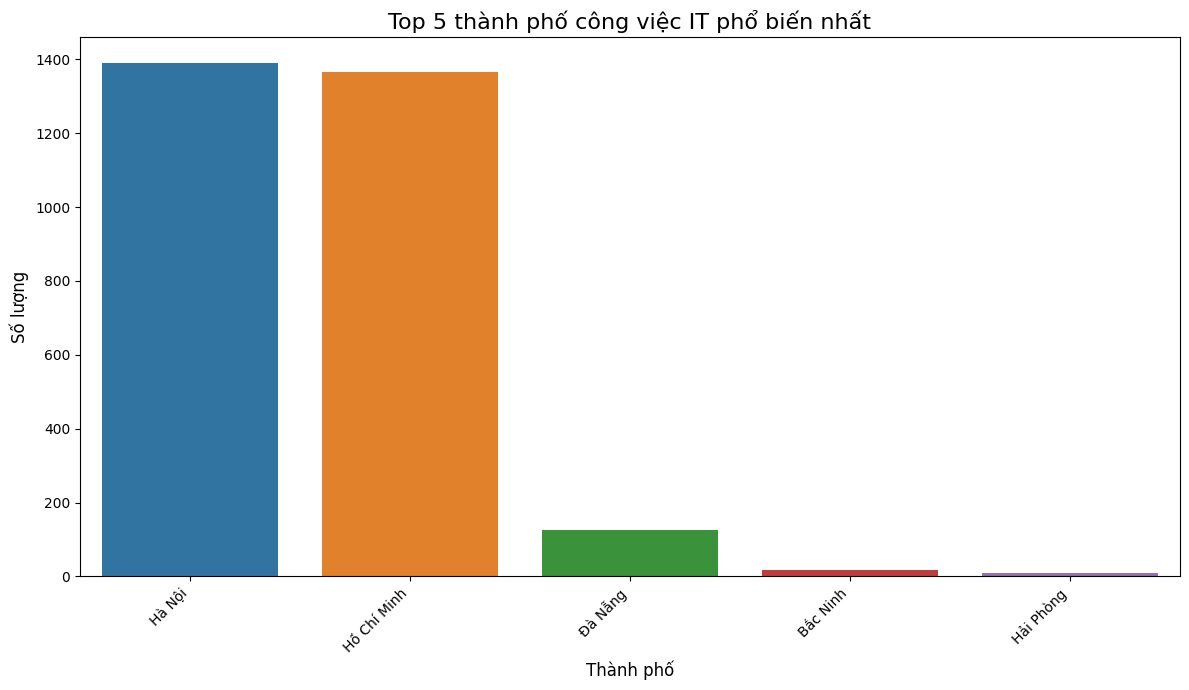

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df_most_common_location, x='City', y='Jobs', hue='City', legend=False)

plt.title(f'Top {top_city-1} thành phố công việc IT phổ biến nhất', fontsize=16)
plt.xlabel('Thành phố', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X để dễ đọc
plt.tight_layout()
plt.show()

## IT_ROLE_TYPE

In [ ]:
recommendation_df = jd[['it_role_type', 'main_programming_languages', 'key_technologies']]
recommendation_df

,it_role_type,main_programming_languages,key_technologies
0,Mobile Developer,['Swift'],"['xCode', 'Realm', 'REST', 'JSON', 'Objective-C']"
1,Full Stack Developer,"['Java', 'JavaScript', 'HTML/CSS']","['Spring Boot', 'Angular', 'React', 'Agile']"
2,Frontend Engineer,['TypeScript'],"['Next.js', 'Tailwind CSS']"
3,System Engineer,['Python'],"['JIRA Service Management', 'Confluence', 'Ops..."
4,QA Engineer,[],"['Agile', 'Automated Testing', 'Performance Te..."
...,...,...,...
3096,Full Stack Developer,"['JavaScript', 'NodeJS']","['React', 'AWS', 'Google Cloud', 'Kafka', 'Doc..."
3097,Backend Engineer,"['Python', 'Node.js']","['AWS', 'Serverless Architecture', 'CI/CD', 'I..."
3098,Backend Engineer,"['PHP', 'HTML', 'CSS', 'JavaScript', 'SQL']","['WordPress', 'SEO', 'Git']"
3099,Full Stack Developer,"['Python', 'C', 'JavaScript']","['Django', 'FastAPI', 'Flask', 'React', 'Flutt..."


In [ ]:
list_job = recommendation_df['it_role_type'].unique()
total_job = recommendation_df['it_role_type'].nunique()

counter_job = Counter(recommendation_df['it_role_type'])
# print(list_job)
print(len(recommendation_df))
print("Total job: ", total_job)
print(counter_job)

3101
Total job:  55
Counter({'Backend Engineer': 572, 'Software Engineer': 341, 'Full Stack Developer': 324, 'Frontend Engineer': 321, 'Other IT Role': 217, 'Mobile Developer': 212, 'QA Engineer': 176, 'Java Engineer': 94, 'AI Engineer': 91, 'Technical Lead': 65, 'Game Developer': 64, 'Embedded Engineer': 56, 'Data Engineer': 54, 'DevOps Engineer': 52, 'Business Analyst': 50, 'IT Project Manager': 39, 'Not Specified': 33, 'Cybersecurity Engineer': 29, 'Bridge Engineer': 27, 'C/C++ Engineer': 27, 'System Engineer': 22, 'Solution Architect': 21, 'Product Manager': 18, 'Database Engineer': 18, '.NET Developer': 18, 'Blockchain Engineer': 17, 'Cloud Engineer': 11, 'IT Manager': 11, 'System Administrator': 11, 'Engineering Manager': 10, 'UI/UX Designer': 10, 'Data Analyst': 10, 'IT Specialist': 9, 'Data Scientist': 8, 'Unity Developer': 8, 'Odoo Developer': 7, 'Flutter Developer': 6, 'Python Engineer': 5, 'Senior Software Engineer': 4, 'Salesforce Developer': 4, 'Education Staff': 4, 'API I

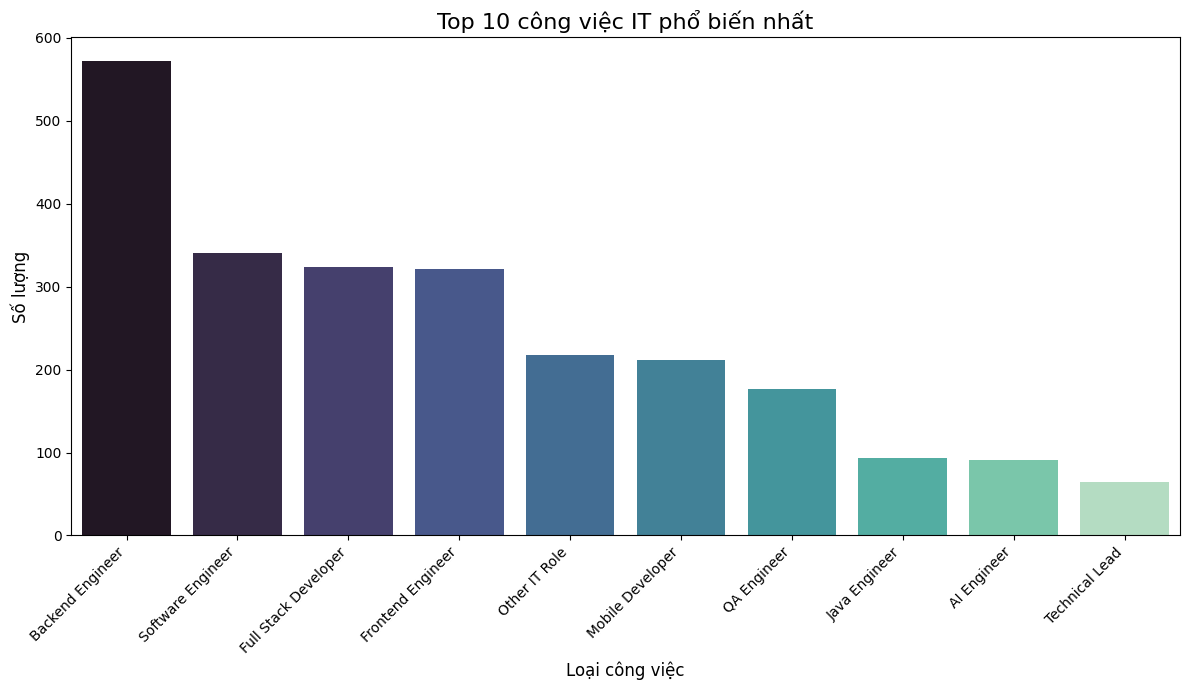

In [ ]:
top_job = 10
most_common_jobs = counter_job.most_common(top_job)
df_most_common = pd.DataFrame(most_common_jobs, columns=['Job_Type', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(data=df_most_common, x='Job_Type', y='Count', palette='mako', hue='Job_Type', legend=False)

plt.title(f'Top {top_job} công việc IT phổ biến nhất', fontsize=16)
plt.xlabel('Loại công việc', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X để dễ đọc
plt.tight_layout()
plt.show()

In [ ]:
jd['it_role_type'] = (
    jd['it_role_type']
    .str.lower()  # chuyển về chữ thường
    .str.replace('-', ' ')  # thay dấu gạch bằng khoảng trắng
    .str.replace(r'\s+', ' ', regex=True)  # chuẩn hóa khoảng trắng thừa
    .str.strip()  # bỏ khoảng trắng đầu cuối
)

# jd['it_role_type'] = jd['it_role_type'].replace(normalize_map)

# --- Sau đó mới viết hoa chữ cái đầu ---
jd['it_role_type'] = jd['it_role_type'].str.title()

## Programming Language

In [ ]:
import ast
def safe_literal_eval(s):
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return []

recommendation_df['main_programming_languages'] = recommendation_df['main_programming_languages'].apply(safe_literal_eval)
recommendation_df['key_technologies'] = recommendation_df['key_technologies'].apply(safe_literal_eval)

/tmp/ipython-input-3922566680.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recommendation_df['main_programming_languages'] = recommendation_df['main_programming_languages'].apply(safe_literal_eval)
/tmp/ipython-input-3922566680.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recommendation_df['key_technologies'] = recommendation_df['key_technologies'].apply(safe_literal_eval)


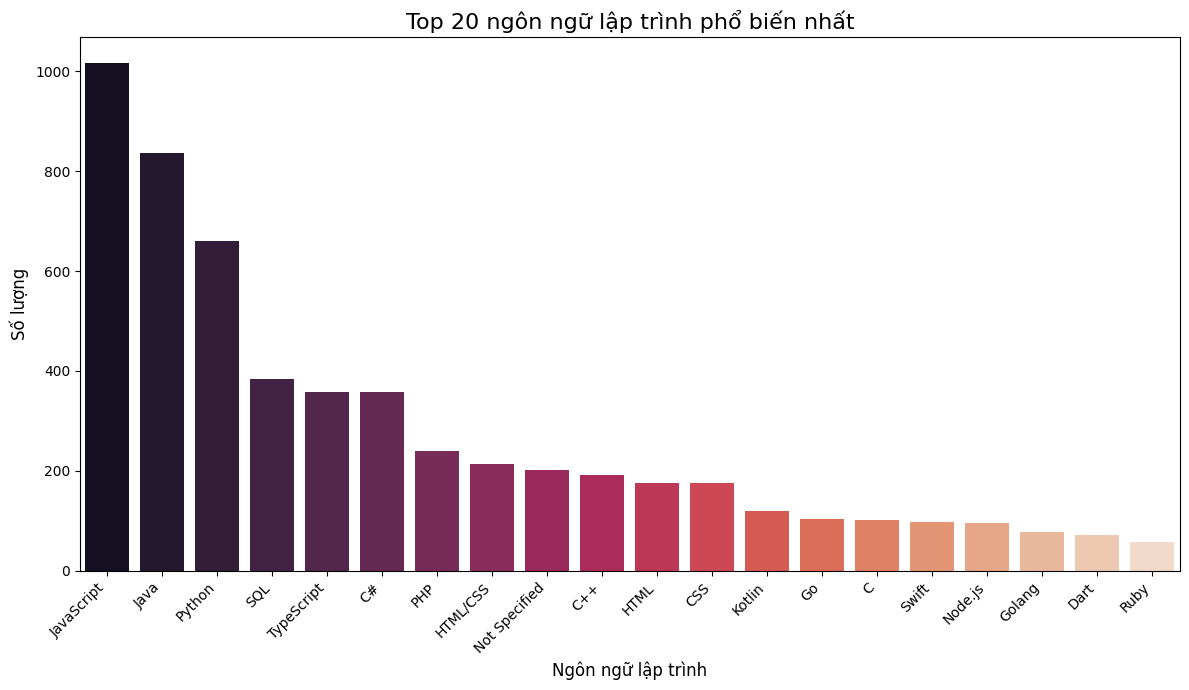

In [ ]:
top_k_programming = 20
all_languages = [lang for sublist in recommendation_df['main_programming_languages'] for lang in sublist]

counter_lang = Counter(all_languages)

most_common_langs = counter_lang.most_common(top_k_programming)
df_langs = pd.DataFrame(most_common_langs, columns=['Language', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(data=df_langs, x='Language', y='Count', palette='rocket', hue='Language', legend=False)
plt.title(f'Top {top_k_programming} ngôn ngữ lập trình phổ biến nhất', fontsize=16)
plt.xlabel('Ngôn ngữ lập trình', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Key technology

/tmp/ipython-input-955509761.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_techs, x='Technology', y='Count', palette='crest')


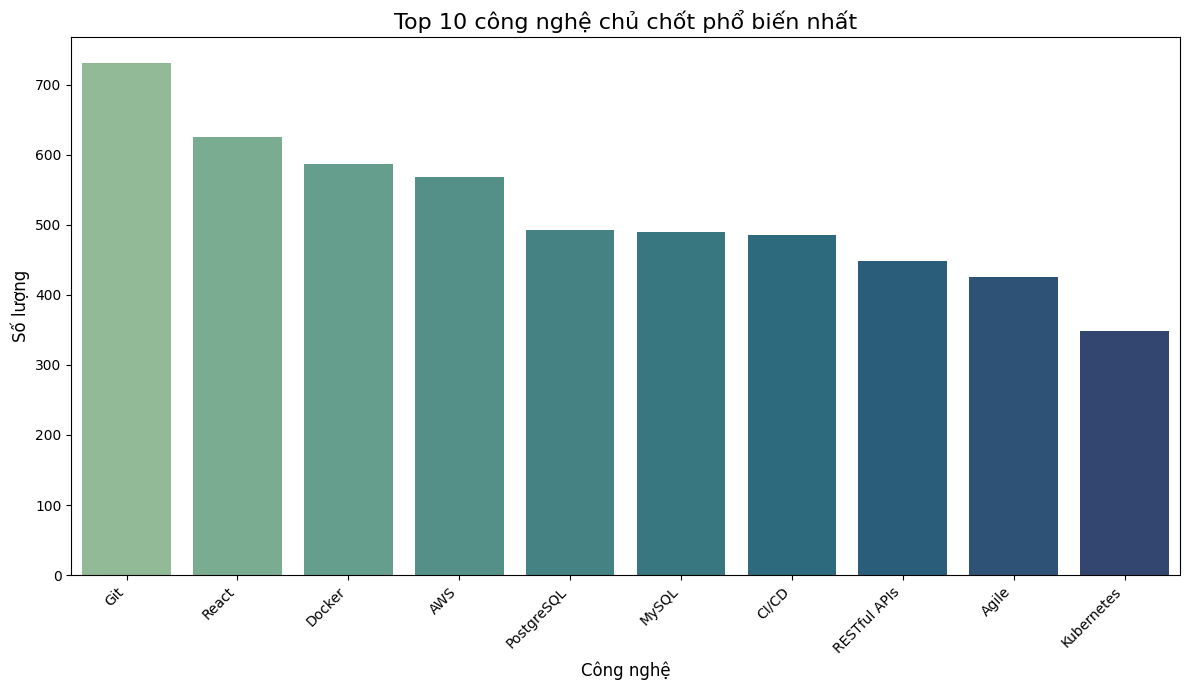

In [ ]:
top_k_tech = 10
all_techs = [tech for sublist in recommendation_df['key_technologies'] for tech in sublist]

counter_tech = Counter(all_techs)

most_common_techs = counter_tech.most_common(top_k_tech)
df_techs = pd.DataFrame(most_common_techs, columns=['Technology', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(data=df_techs, x='Technology', y='Count', palette='crest')
plt.title(f'Top {top_k_tech} công nghệ chủ chốt phổ biến nhất', fontsize=16)
plt.xlabel('Công nghệ', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mining with Machine Learning

# Job Cluster

## Embedding feature with SentenceTransformer

### Đi tìm K tốt nhất với từng embedder

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch
multilingual_embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embedder = SentenceTransformer('all-MiniLM-L12-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
jd[['it_role_type', 'main_programming_languages', 'key_technologies']]

,it_role_type,main_programming_languages,key_technologies
0,Mobile Developer,['Swift'],"['xCode', 'Realm', 'REST', 'JSON', 'Objective-C']"
1,Full Stack Developer,"['Java', 'JavaScript', 'HTML/CSS']","['Spring Boot', 'Angular', 'React', 'Agile']"
2,Frontend Engineer,['TypeScript'],"['Next.js', 'Tailwind CSS']"
3,System Engineer,['Python'],"['JIRA Service Management', 'Confluence', 'Ops..."
4,Qa Engineer,[],"['Agile', 'Automated Testing', 'Performance Te..."
...,...,...,...
3096,Full Stack Developer,"['JavaScript', 'NodeJS']","['React', 'AWS', 'Google Cloud', 'Kafka', 'Doc..."
3097,Backend Engineer,"['Python', 'Node.js']","['AWS', 'Serverless Architecture', 'CI/CD', 'I..."
3098,Backend Engineer,"['PHP', 'HTML', 'CSS', 'JavaScript', 'SQL']","['WordPress', 'SEO', 'Git']"
3099,Full Stack Developer,"['Python', 'C', 'JavaScript']","['Django', 'FastAPI', 'Flask', 'React', 'Flutt..."


In [ ]:
job_text = jd.apply(lambda row: " ".join([
    # row['title'],
    row['it_role_type'],
    " ".join(eval(row['main_programming_languages'])),
    " ".join(eval(row['key_technologies'])),
]), axis=1)

In [ ]:
job_text

,0
0,Mobile Developer Swift xCode Realm REST JSON O...
1,Full Stack Developer Java JavaScript HTML/CSS ...
2,Frontend Engineer TypeScript Next.js Tailwind CSS
3,System Engineer Python JIRA Service Management...
4,Qa Engineer Agile Automated Testing Performan...
...,...
3096,Full Stack Developer JavaScript NodeJS React A...
3097,Backend Engineer Python Node.js AWS Serverless...
3098,Backend Engineer PHP HTML CSS JavaScript SQL W...
3099,Full Stack Developer Python C JavaScript Djang...


In [ ]:
job_text_embedding = embedder.encode(job_text)
job_text_embedding_mulitlingual = multilingual_embedder.encode(job_text)

In [ ]:
job_text_embedding.shape, job_text_embedding_mulitlingual.shape

((3101, 384), (3101, 384))

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
def silhouette_score(embm, name):
  # from sklearn.cluster import KMeans
  # from sklearn.metrics import silhouette_score
  # import matplotlib.pyplot as plt
  scores = []
  K = range(2, 10)

  for k in K:
      model = KMeans(n_clusters=k, random_state=42)
      preds = model.fit_predict(embm)
      score = silhouette_score(embm, preds)
      print(k, round(score, 4))
      scores.append(score)

  plt.figure(figsize=(8,5))
  plt.plot(K, scores, 'go-')
  plt.xlabel('Số cụm (k)')
  plt.ylabel('Silhouette Score')
  plt.title(f'Silhouette Score với {name}')
  plt.show()

In [ ]:
def clustering_score(embm, name):
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    import matplotlib.pyplot as plt
    import numpy as np

    scores_silhouette = []
    inertias = []  # dùng cho Elbow
    K = range(2, 10)

    for k in K:
        model = KMeans(n_clusters=k, random_state=42)
        preds = model.fit_predict(embm)
        sil_score = silhouette_score(embm, preds)
        inertia = model.inertia_  # tổng bình phương khoảng cách đến tâm cụm

        scores_silhouette.append(sil_score)
        inertias.append(inertia)
        print(f"k={k} | Silhouette={sil_score:.4f} | Inertia={inertia:.2f}")

    # --- Vẽ 2 biểu đồ cạnh nhau ---
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))

    # 1️⃣ Biểu đồ Silhouette
    ax[0].plot(K, scores_silhouette, 'go-', linewidth=2, markersize=8)
    ax[0].set_title(f"Silhouette Score vs k ({name})", fontsize=13)
    ax[0].set_xlabel("Số cụm (k)")
    ax[0].set_ylabel("Silhouette Score")
    ax[0].grid(True, linestyle='--', alpha=0.6)

    # 2️⃣ Biểu đồ Elbow Method
    ax[1].plot(K, inertias, 'bo-', linewidth=2, markersize=8)
    ax[1].set_title(f"Elbow Method vs k ({name})", fontsize=13)
    ax[1].set_xlabel("Số cụm (k)")
    ax[1].set_ylabel("Inertia (WCSS)")
    ax[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


k=2 | Silhouette=0.0750 | Inertia=2054.70
k=3 | Silhouette=0.0733 | Inertia=1929.78
k=4 | Silhouette=0.0664 | Inertia=1879.12
k=5 | Silhouette=0.0580 | Inertia=1830.31
k=6 | Silhouette=0.0680 | Inertia=1772.56
k=7 | Silhouette=0.0653 | Inertia=1736.14
k=8 | Silhouette=0.0792 | Inertia=1673.71
k=9 | Silhouette=0.0821 | Inertia=1640.04


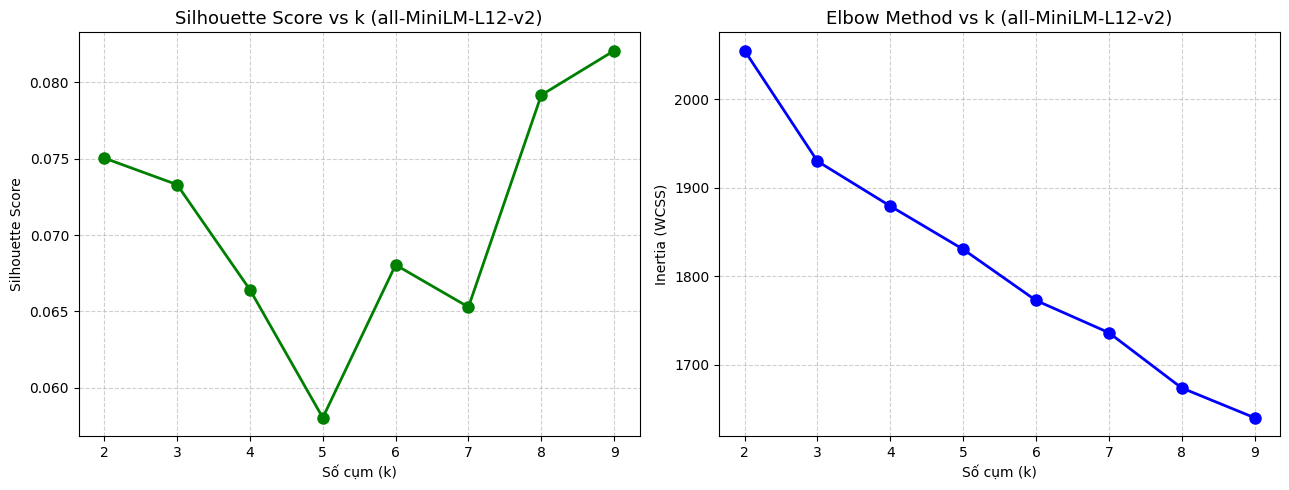

In [ ]:
clustering_score(job_text_embedding, 'all-MiniLM-L12-v2')

k=2 | Silhouette=0.0691 | Inertia=32730.31
k=3 | Silhouette=0.0605 | Inertia=30791.44
k=4 | Silhouette=0.0671 | Inertia=29985.70
k=5 | Silhouette=0.0774 | Inertia=28888.60
k=6 | Silhouette=0.0844 | Inertia=28078.39
k=7 | Silhouette=0.0850 | Inertia=27514.26
k=8 | Silhouette=0.0903 | Inertia=27027.23
k=9 | Silhouette=0.0958 | Inertia=26310.21


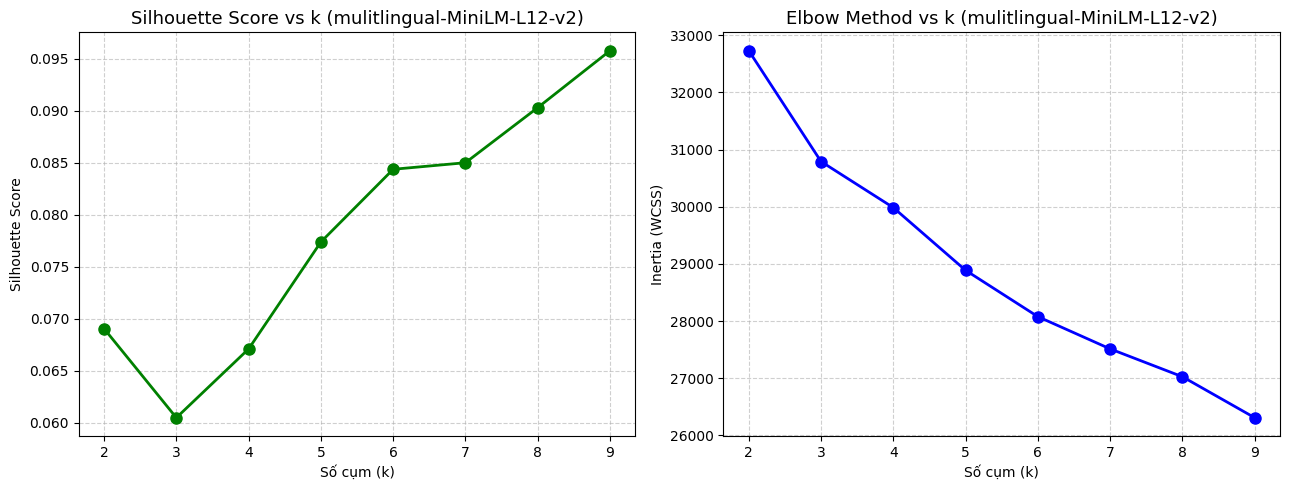

In [ ]:
clustering_score(job_text_embedding_mulitlingual, 'mulitlingual-MiniLM-L12-v2')

## Visual các nhóm group với PCA

In [ ]:
def pca_visualization(embeddings, k, name="Model"):

    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans
    import matplotlib.pyplot as plt

    # 1️⃣ Huấn luyện mô hình KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(embeddings)

    # 2️⃣ Giảm chiều dữ liệu về 2D bằng PCA
    pca = PCA(n_components=2, random_state=42)
    x_pca = pca.fit_transform(embeddings)

    # 3️⃣ Vẽ biểu đồ
    plt.figure(figsize=(12, 8))
    for cluster_id in range(k):
        plt.scatter(
            x_pca[cluster_labels == cluster_id, 0],
            x_pca[cluster_labels == cluster_id, 1],
            label=f"Cluster {cluster_id}",
            s=50,
        )

    plt.title(f"PCA Visualization of Clusters (k={k}) - {name}", fontsize=14)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title="Cụm", loc="best")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return cluster_labels  # trả về nhãn cụm để dùng tiếp nếu cần


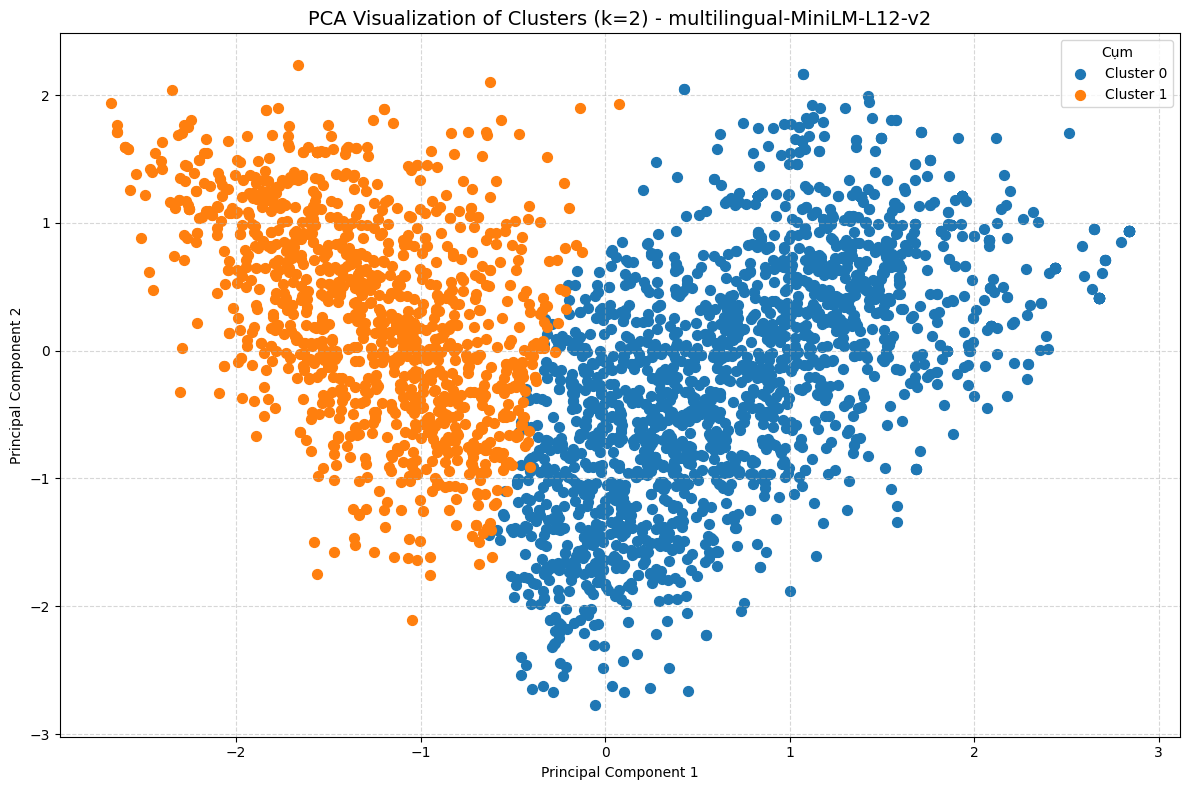

In [ ]:
# với multilingual
cluster_labels = pca_visualization(job_text_embedding_mulitlingual, k=2, name="multilingual-MiniLM-L12-v2")

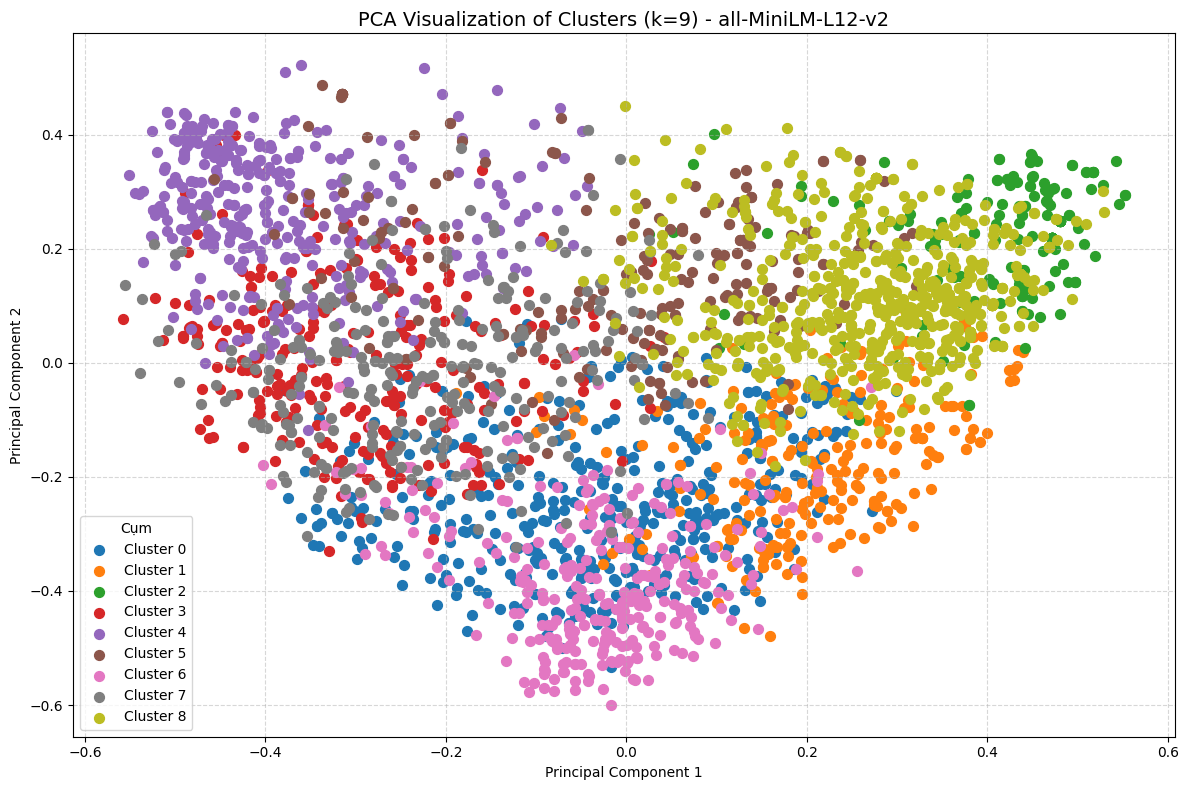

array([5, 4, 4, ..., 7, 3, 2], dtype=int32)

In [ ]:
# với all
pca_visualization(job_text_embedding, k=9, name="all-MiniLM-L12-v2")

In [ ]:
def pca_visualization_3d(embeddings, k, name="Embedding Model", show_centers=True):

    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import seaborn as sns
    import numpy as np

    # KMeans Clustering
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(embeddings)

    pca_3d = PCA(n_components=3, random_state=42)
    x_pca_3d = pca_3d.fit_transform(embeddings)

    # Chuyển tâm cụm sang không gian PCA (nếu cần vẽ)
    if show_centers:
        centers_pca = pca_3d.transform(km.cluster_centers_)

    # Vẽ biểu đồ 3D
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    palette = sns.color_palette("husl", k)

    for cluster_id in range(k):
        ax.scatter(
            x_pca_3d[cluster_labels == cluster_id, 0],
            x_pca_3d[cluster_labels == cluster_id, 1],
            x_pca_3d[cluster_labels == cluster_id, 2],
            s=60,
            color=palette[cluster_id],
            label=f"Cluster {cluster_id}",
            alpha=0.8,
        )

    # Hiển thị tâm cụm
    if show_centers:
        ax.scatter(
            centers_pca[:, 0],
            centers_pca[:, 1],
            centers_pca[:, 2],
            c="black",
            s=200,
            marker="D",
            edgecolor="white",
            linewidth=1.5,
            label="Cluster Centers",
        )

    # Tùy chỉnh giao diện
    ax.set_title(
        f"3D Visualization of KMeans Clusters (k={k}) - {name}",
        fontsize=13,
        pad=20,
    )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_zlabel("Principal Component 3")
    ax.legend(title="Cluster", loc="best")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.view_init(elev=25, azim=120)

    plt.tight_layout()
    plt.show()

    return cluster_labels, x_pca_3d


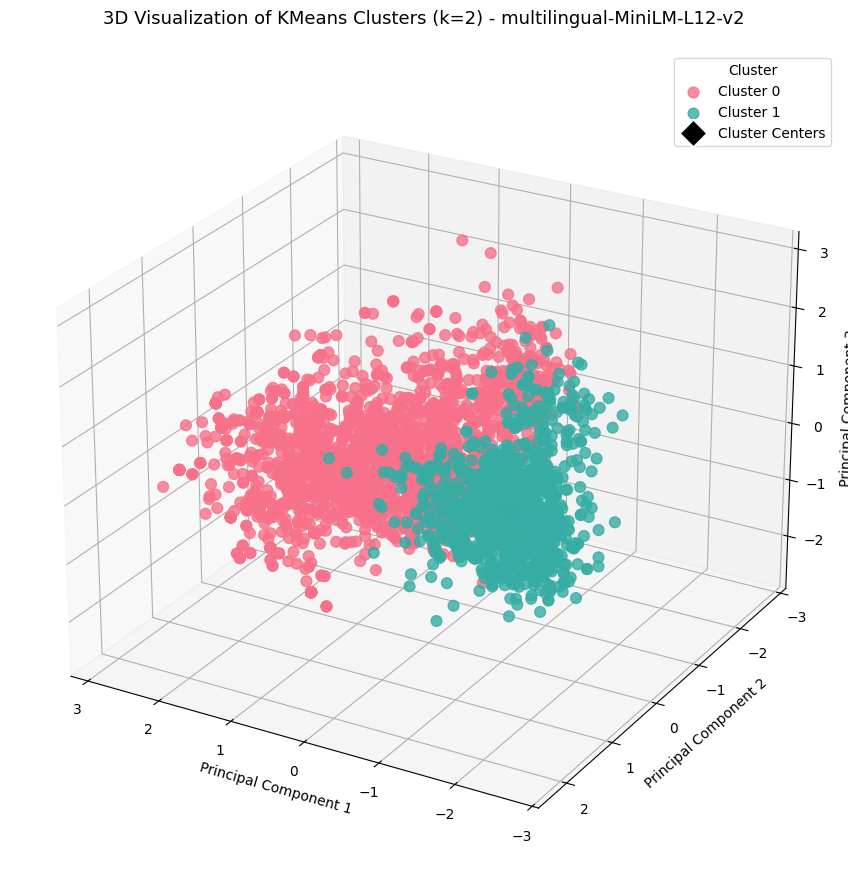

In [ ]:
labels_3d, reduced_3d = pca_visualization_3d(
    job_text_embedding_mulitlingual,
    k=2,
    name="multilingual-MiniLM-L12-v2",
    show_centers=True
)

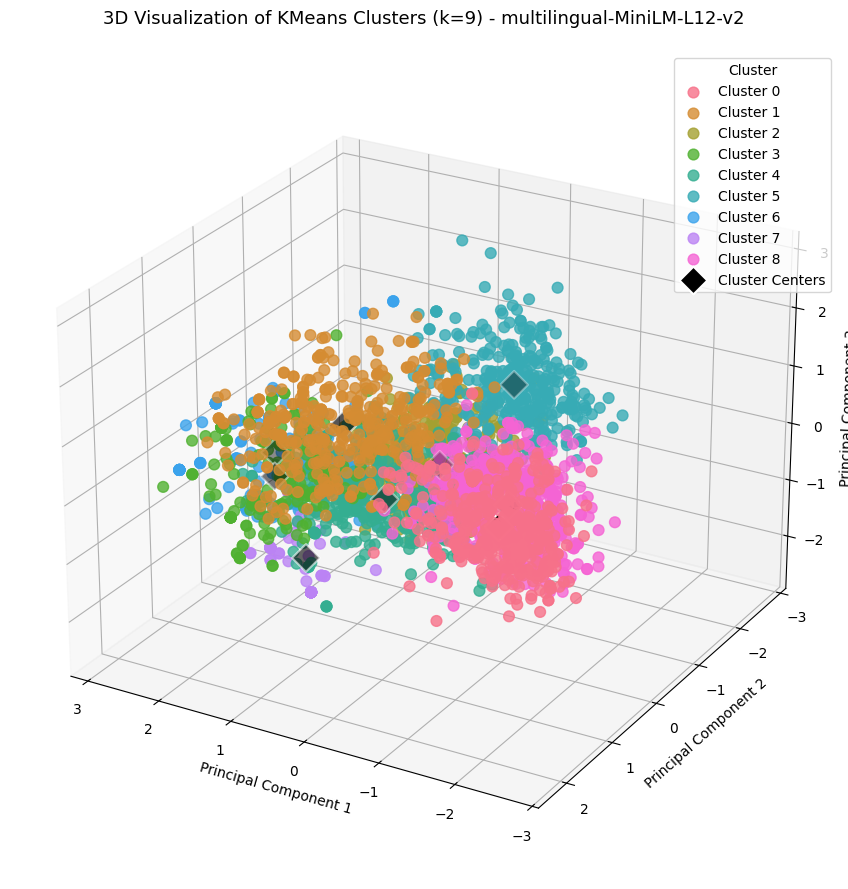

In [ ]:
labels_3d, reduced_3d = pca_visualization_3d(
    job_text_embedding_mulitlingual,
    k=9,
    name="multilingual-MiniLM-L12-v2",
    show_centers=True
)

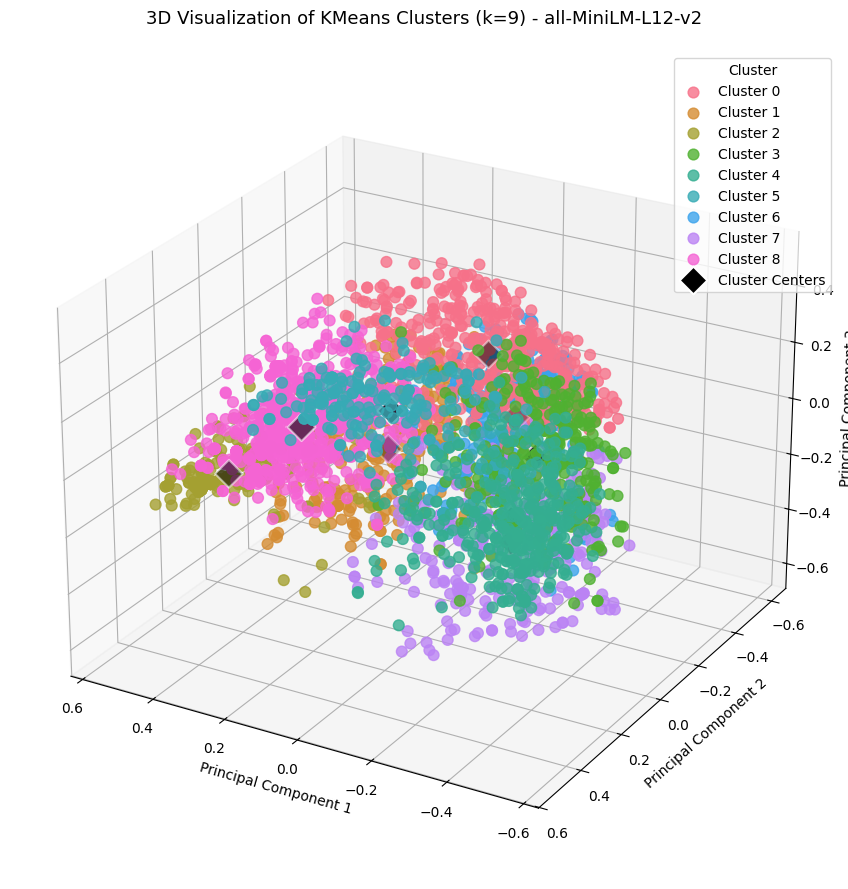

In [ ]:
labels_3d, reduced_3d = pca_visualization_3d(
    job_text_embedding,
    k=9,
    name="all-MiniLM-L12-v2",
    show_centers=True
)

## Final k and embedder

In [ ]:
# Cuối cùng chọn 7 để phân tích được nhiều nhóm ngành
k = 9
km = KMeans(n_clusters=k, random_state = 42)
jd['cluster'] = km.fit_predict(job_text_embedding_mulitlingual)

In [ ]:
cluster_df = pd.DataFrame(jd.groupby('cluster')['it_role_type'].value_counts())

# Association Rule

In [ ]:
print(jd.columns)
association_rule = jd[['title' ,'it_role_type', 'main_programming_languages', 'key_technologies', 'cluster']]

Index(['Unnamed: 0', 'title', 'company', 'company_image_url', 'location',
       'description', 'site', 'job_url', 'it_role_type',
       'main_programming_languages', 'key_technologies', 'city', 'cluster'],
      dtype='object')


In [ ]:
import warnings
warnings.filterwarnings("ignore", message="datetime.datetime.utcnow() is deprecated")
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Phân tích theo từng cluster

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import ast
clusters = association_rule['cluster'].unique()

# Lặp qua từng cluster để khai phá luật kết hợp
for cluster_id in sorted(clusters):
    print(f"\n\n===== Phân tích cho Cluster {cluster_id} =====")

    # 1. Lọc dữ liệu cho cluster hiện tại
    df_cluster = jd[jd['cluster'] == cluster_id].copy()

    if df_cluster.empty:
        print(f"Cluster {cluster_id} không có dữ liệu.")
        continue

    # 2. Tạo "Giao dịch" từ các cột liên quan
    transactions = []
    for index, row in df_cluster.iterrows():
        # Bắt đầu với vai trò IT
        items = [row['it_role_type']]
        try:
            langs = ast.literal_eval(row['main_programming_languages'])
            items.extend(langs)
        except (ValueError, SyntaxError):
            pass
        try:
            techs = ast.literal_eval(row['key_technologies'])
            items.extend(techs)
        except (ValueError, SyntaxError):
            pass

        transactions.append(items)

    print(f"Ví dụ một vài giao dịch trong Cluster {cluster_id}:")
    for i in range(min(2, len(transactions))):
        print(transactions[i])

    # 3. Chuyển đổi dữ liệu giao dịch sang dạng One-Hot Encoding
    # Đây là định dạng đầu vào yêu cầu bởi thuật toán Apriori
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

    # 4. Áp dụng thuật toán Apriori để tìm các tập hợp phổ biến
    min_support = 0.1
    frequent_itemsets = apriori(df_onehot, min_support=min_support, use_colnames=True)

    if frequent_itemsets.empty:
        print(f"\nKhông tìm thấy tập hợp phổ biến nào với min_support={min_support} trong Cluster {cluster_id}.")
        print("Gợi ý: Hãy thử giảm giá trị `min_support`.")
        continue

    print(f"\nCác tập hợp phổ biến (Frequent Itemsets) trong Cluster {cluster_id}:")
    print("Với min_support=", min_support)
    print(frequent_itemsets)

    # 5. Tạo luật kết hợp từ các tập hợp phổ biến
    min_threshold = 1.0
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_threshold)

    if rules.empty:
        print(f"\nKhông tìm thấy luật kết hợp nào thỏa mãn điều kiện (lift > {min_threshold}) trong Cluster {cluster_id}.")
        continue

    # 6. Hiển thị kết quả
    # Sắp xếp các luật theo 'lift' và 'confidence' để dễ dàng xem các luật mạnh nhất
    rules_sorted = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

    print(f"\nCác luật kết hợp tìm được trong Cluster {cluster_id}:")
    print("Với threadshold=", min_threshold)
    print(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']])



===== Phân tích cho Cluster 0 =====
Ví dụ một vài giao dịch trong Cluster 0:
['Frontend Engineer', 'TypeScript', 'Next.js', 'Tailwind CSS']
['Frontend Engineer', 'JavaScript', 'HTML5', 'CSS3', 'TypeScript', 'Angular']

Các tập hợp phổ biến (Frequent Itemsets) trong Cluster 0:
Với min_support= 0.1
     support                                           itemsets
0   0.176761                                              (AWS)
1   0.118665                                            (Agile)
2   0.156984                                          (Angular)
3   0.131026                                 (Backend Engineer)
4   0.102596                                               (C#)
..       ...                                                ...
94  0.128554                  (RESTful APIs, JavaScript, React)
95  0.197775                    (TypeScript, JavaScript, React)
96  0.124845                        (JavaScript, React, Vue.js)
97  0.119901        (Frontend Engineer, JavaScript, React, G

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ví dụ một vài giao dịch trong Cluster 6:
['Full Stack Developer', 'Java', 'JavaScript', 'HTML/CSS', 'Spring Boot', 'Angular', 'React', 'Agile']
['Full Stack Developer', 'Java', 'JavaScript', 'React', 'Spring Boot', 'RESTful APIs', 'MySQL']

Các tập hợp phổ biến (Frequent Itemsets) trong Cluster 6:
Với min_support= 0.1
      support                                 itemsets
0    0.292818                                    (AWS)
1    0.187845                                  (Agile)
2    0.118785                                (Angular)
3    0.104972                                  (Azure)
4    0.397790                       (Backend Engineer)
..        ...                                      ...
202  0.124309  (Docker, PostgreSQL, Java, Spring Boot)
203  0.104972        (Kafka, Java, MySQL, Spring Boot)
204  0.118785        (Java, Kafka, Redis, Spring Boot)
205  0.124309      (MongoDB, Java, MySQL, Spring Boot)
206  0.127072   (PostgreSQL, Java, MySQL, Spring Boot)

[207 rows x 2 colum

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated

# Job Recommendation System

## Embedding Job_Description với Multilingual Model bổ sung thêm các cột title, description, city

In [ ]:
job_desc_embedding = multilingual_embedder.encode(
    jd.apply(lambda row: f"{row['title']} {row['description']} {row['city']}", axis=1).tolist()
)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().

## Essemble của skill embedding với description embedding

In [ ]:
# ESSEMBLE
w_finding_en = 0.6
w_impressions_en = 1 - w_finding_en
embeddings = Finding_EN*w_description + Impressions_EN*w_skill

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

candidate_skills = 'Front-End Developer with 4 years of experience at Tech Solutions Inc. and Web Innovations Co., specializing in React.js, JavaScript (ES6+), HTML5, CSS3, Redux, TypeScript, and RESTful APIs for building responsive web applications.'
candidate_skills_1 = "Backend Developer with 5 years of experience at CloudNova and DataFlow Systems, proficient in Node.js, Express.js, PostgreSQL, MongoDB, and Docker, focusing on scalable API design and microservices architecture."
candidate_skills_3 = "Mobile Developer with 4 years of experience at AppStudio and PixelWorks, specializing in Flutter, Dart, Kotlin, and Firebase for building cross-platform mobile apps with smooth UI/UX."
candidate_skills_10 = "AI Engineer with 4 years of experience at VisionAI and Phenikaa-X Lab, proficient in PyTorch, OpenCV, Transformers, and FastAPI, focusing on computer vision and natural language processing applications."


candidate_vec = multilingual_embedder.encode(candidate_skills_10)

similarities = util.cos_sim(candidate_vec, embeddings).flatten()

# Top 10 gợi ý
jd['similarity'] = similarities
recommendations = jd.sort_values('similarity', ascending=False).head(10)
print(candidate_skills)
recommendations[['title', 'company', 'similarity', 'main_programming_languages', 'key_technologies', 'cluster', 'it_role_type']]

Front-End Developer with 4 years of experience at Tech Solutions Inc. and Web Innovations Co., specializing in React.js, JavaScript (ES6+), HTML5, CSS3, Redux, TypeScript, and RESTful APIs for building responsive web applications.


,title,company,similarity,main_programming_languages,key_technologies,cluster,it_role_type
3054,AI Developer,CÔNG TY TNHH NERDWARE TECHNOLOGY,0.743244,['Python'],"['GAN', 'Deep Learning', 'Computer Vision', 'D...",8,Ai Engineer
880,"Senior AI/NLP Engineer (Python, PyTorch)",DNSE,0.720744,['Python'],['PyTorch'],8,Ai Engineer
1407,"Kỹ sư Phát triển AI - AI Engineer (Python,C++)...",MBBank,0.716456,"['Python', 'C++']","['TensorFlow', 'PyTorch', 'FastAPI', 'Flask', ...",8,Ai Engineer
1696,[HN] AI ENGINEER - COMPUTER VISION,CMC Technology & Solution (CMC TS),0.705510,['Python'],"['Computer Vision', 'MLOps', 'Jetson Devices',...",8,Ai Engineer
1643,AI Engineer (Computer Vision),Elcom Corporation,0.705145,"['Python', 'C++']","['PyTorch', 'TensorFlow', 'OpenCV', 'HuggingFa...",8,Ai Engineer
1717,AI/ML Engineer (Automation & Computer Vision),Wanek Furniture,0.704385,['Python'],"['TensorFlow', 'PyTorch', 'OpenCV', 'UiPath', ...",8,Ai Engineer
1686,Computer Vision Engineer,Aimesoft,0.700733,"['Python', 'C/C++']","['TensorFlow', 'PyTorch', 'Keras']",8,Ai Engineer
1506,[ELCOM Hà Nội] Kỹ sư AI (Computer Vision),Elcom Corporation,0.700582,"['Python', 'C++']","['PyTorch', 'TensorFlow', 'OpenCV', 'HuggingFa...",8,Ai Engineer
1078,Chuyên viên chính Trí tuệ nhân tạo,Viettel High Tech,0.694015,"['C++', 'Python', 'Java']","['MLOps', 'Cloud', 'Computer Vision']",8,Ai Engineer
2453,AI Developer,CÔNG TY TNHH NERDWARE TECHNOLOGY,0.685608,['Python'],"['GAN', 'Diffusion Models', 'UNet', 'Transform...",2,Ai Engineer


In [ ]:
for i in range(10):
  print(f"Công ty thứ {i+1}")
  print(recommendations.iloc[i])
  print('-'*80)

Công ty thứ 1
Unnamed: 0                                                                 3054
title                                                              AI Developer
company                                        CÔNG TY TNHH NERDWARE TECHNOLOGY
company_image_url             https://cdn-new.topcv.vn/unsafe/80x/https://st...
location                                                                 Hà Nội
description                   1. Giới thiệu công việc\nChúng tôi đang tìm ki...
site                                                                      TopCV
job_url                       https://www.topcv.vn/viec-lam/ai-developer/175...
it_role_type                                                        Ai Engineer
main_programming_languages                                           ['Python']
key_technologies              ['GAN', 'Deep Learning', 'Computer Vision', 'D...
city                                                                     Hà Nội
cluster                   

## Thử với Resume | CV thực tế

### Viết CV với langchain

In [ ]:
# !pip uninstall -y langchain langchain-core langchain-community langchain-google-genai

Found existing installation: langchain 1.0.1
Uninstalling langchain-1.0.1:
  Successfully uninstalled langchain-1.0.1
Found existing installation: langchain-core 1.0.0
Uninstalling langchain-core-1.0.0:
  Successfully uninstalled langchain-core-1.0.0
Found existing installation: langchain-community 0.4
Uninstalling langchain-community-0.4:
  Successfully uninstalled langchain-community-0.4
Found existing installation: langchain-google-genai 3.0.0
Uninstalling langchain-google-genai-3.0.0:
  Successfully uninstalled langchain-google-genai-3.0.0


In [ ]:
# !pip install -U langchain langchain-core langchain-community langchain-google-genai

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain.chains.llm import LLMChain
from langchain_google_genai import ChatGoogleGenerativeAI

ModuleNotFoundError: No module named 'langchain.chains'

In [ ]:
api_key = "YOUR_API_KEY"

In [ ]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key = api_key,
    temperature = 1
)

In [ ]:
# --- Prompt ---
template = """
You are an expert resume and CV writer specializing in IT and software engineering.
Create a professional, realistic English CV using the details below.
Keep the format concise, structured, and ATS-friendly.

Information:
Full name: {full_name}
Email: {email}
Phone: {phone}

Education:
- School: {school}
- Major: {major}
- Graduation Year: {graduation}

Target Role: {role_type}

Experience:
- Years: {experience_years}
- Details: {experience_detail}

Technical Skills:
- Programming Languages: {programming_languages}
- Technologies & Frameworks: {technologies}

Projects:
{projects}

Certificates:
{certificates}

Languages:
{languages}

Format:
1. Professional header (name, contact)
2. Summary (short introduction)
3. Education
4. Experience
5. Technical Skills
6. Projects
7. Certificates
8. Languages
"""

prompt = PromptTemplate(
    template=template,
    input_variables=[
        "full_name", "email", "phone",
        "school", "major", "graduation",
        "role_type",
        "experience_years", "experience_detail",
        "programming_languages", "technologies",
        "projects", "certificates", "languages"
    ]
)

chain = LLMChain(llm=llm, prompt=prompt)

In [ ]:
# --- Nhập thông tin cơ bản ---
full_name = input("Họ và tên: ")
email = input("Email: ")
phone = input("Số điện thoại: ")

school = input("Trường tốt nghiệp: ")
major = input("Chuyên ngành: ")
graduation = input("Năm tốt nghiệp: ")

role_type = input("Vị trí IT mong muốn: ")

experience_years = input("Số năm kinh nghiệm: ")
experience_detail = input("Mô tả kinh nghiệm làm việc (ngắn gọn): ")

programming_languages = input("Ngôn ngữ lập trình: ")
technologies = input("Công nghệ / Frameworks: ")
projects = input("Các dự án nổi bật: ")
certificates = input("Chứng chỉ (nếu có): ")
languages = input("Ngôn ngữ sử dụng: ")

In [ ]:
# --- Sinh CV ---
cv_text = chain.run({
    "full_name": full_name,
    "email": email,
    "phone": phone,
    "school": school,
    "major": major,
    "graduation": graduation,
    "role_type": role_type,
    "experience_years": experience_years,
    "experience_detail": experience_detail,
    "programming_languages": programming_languages,
    "technologies": technologies,
    "projects": projects,
    "certificates": certificates,
    "languages": languages
})

print("\n===== CV HOÀN CHỈNH =====\n")
print(cv_text)

In [ ]:
import re

def clean_text(text):
    cleaned = re.sub(r'[\n\*\-\|/]+', ' ', text)
    cleaned = re.sub(r'\s{2,}', ' ', cleaned)
    cleaned = cleaned.strip()
    return cleaned
cv_text = clean_text(cv_text)

In [ ]:
cv_vec = multilingual_embedder.encode(cv_text)

similarities = util.cos_sim(cv_vec, embeddings).flatten()

# Top 10 gợi ý
top_k_suggest = 10

jd['similarity'] = similarities
recommendations = jd.sort_values('similarity', ascending=False).head(top_k_suggest)
print(candidate_skills)
recommendations[['title', 'company', 'similarity', 'main_programming_languages', 'key_technologies', 'cluster']]

In [ ]:
for i in range(10):
  print(f"Công ty thứ {i+1}")
  print(recommendations.iloc[i])
  print('-'*80)